In [9]:
%load_ext autoreload
%autoreload 2

import sys

from pathlib import Path

path = Path("..").resolve().as_posix()
if str(path) not in sys.path:
    sys.path.insert(0, str(path))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[[2.91308879e-06]
 [2.91308879e-06]]
[[0.00291307]
 [0.00291307]]
[[[ 10.00005503   0.        ]]

 [[  0.           0.        ]]

 [[-10.00005503   0.        ]]]


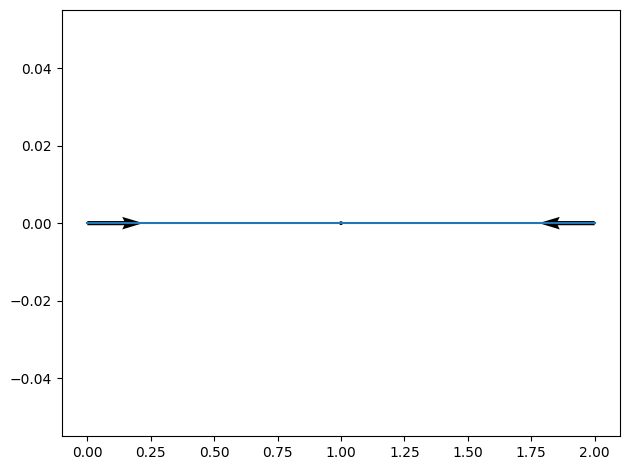

In [8]:
from ael.score_function import compute_velocity_score_batched_helper
import numpy as np
import matplotlib.pyplot as plt

SIGMA = 0.01
# MAX_SPEED = 1.00000000001
MAX_SPEED = 0.999

xy_T_B_D = np.array([[[0.0, 0.0]], [[1.0, 0.0]], [[2.0, 0.0]]])
max_speed_B = np.array([MAX_SPEED])
sigma_B = np.array([SIGMA])
score_T_B_D = compute_velocity_score_batched_helper(
    xy_T_B_D, max_speed_B, sigma_B, n_integral=10
)
# rescale to maximum norm of 100
score_T_B_D = score_T_B_D / (
    np.maximum(1, np.linalg.norm(score_T_B_D, axis=-1, keepdims=True) / 100)
)

print(score_T_B_D)

plt.plot(xy_T_B_D[:, 0, 0], xy_T_B_D[:, 0, 1])
plt.quiver(
    xy_T_B_D[:, 0, 0],
    xy_T_B_D[:, 0, 1],
    score_T_B_D[:, 0, 0],
    score_T_B_D[:, 0, 1],
    scale=100,
)
plt.tight_layout()
plt.show()


In [10]:
from ael.solve import (
    ScheduleEntry,
    compute_score,
    ScoreComputationMethod,
    Problem,
    OptimizerOptions,
    DEFAULT_SCHEDULES,
    Result,
    compute_constraint_residuals
)
from ael.visgraphprior import generate_paths, make_roadmap, interpolate
import time
from loguru import logger


def solve(
    problem: Problem,
    score_computation_method: ScoreComputationMethod,
    optimizer_options: OptimizerOptions = OptimizerOptions(),
    schedule: list[ScheduleEntry] | None = None,
    initial_trajectory: np.ndarray | None = None,
    identifier: str | None = None,
) -> Result:
    t0 = time.time()
    if schedule is None:
        schedule = DEFAULT_SCHEDULES[score_computation_method]

    if score_computation_method in [
        ScoreComputationMethod.UNFACTORIZED_MPPI,
        ScoreComputationMethod.FACTORIZED_MPPI,
    ]:
        # step_size_ok = all(s.step_size == 1 for s in schedule)
        step_size_ok = True
        assert optimizer_options.kind == "sgd" and step_size_ok, (
            "MPPI computations require SGD with a step size of 1 for true equivalence."
        )

    # TODO: Initialize from prior distribution based on energy.
    start_positions = problem.agent_start_positions
    end_positions = problem.agent_end_positions

    trajectory = np.linspace(start_positions, end_positions, num=64, axis=0)

    trajectory[0] = start_positions
    trajectory[-1] = end_positions

    # Adam parameters.
    score_m: np.ndarray = np.zeros_like(trajectory)
    score_v: np.ndarray = np.zeros_like(trajectory)
    beta1_t = 1.0
    beta2_t = 1.0

    trajectories = []

    dt = 1.0

    graph, vertices = make_roadmap(problem)
    target_paths_by_agent = []
    for agent_index in range(problem.num_agents):
        paths = generate_paths(
            graph,
            vertices,
            start_positions[agent_index],
            end_positions[agent_index],
            num_paths=5,
        )
        paths_interpolated = []
        for path in paths:
            for speed in [
                0.2 * problem.agent_max_speeds[agent_index],
                0.5 * problem.agent_max_speeds[agent_index],
                0.8 * problem.agent_max_speeds[agent_index],
                problem.agent_max_speeds[agent_index],
            ]:
                path_length = np.linalg.norm(np.diff(path, axis=0), axis=-1).sum()
                min_speed = path_length / (problem.num_timesteps * dt) + 0.01
                speed = max(speed, min_speed)
                interpolated = interpolate(path, dt, speed)
                interpolated_path_timesteps = interpolated.shape[0]
                if interpolated_path_timesteps > problem.num_timesteps:
                    print(interpolated_path_timesteps)
                    continue

                path = np.zeros((problem.num_timesteps, 2))
                path[:interpolated_path_timesteps] = interpolated
                path[interpolated_path_timesteps:] = interpolated[-1]
                paths_interpolated.append(path)

            if len(paths_interpolated) == 0:
                logger.warning(
                    "No path found for agent %d that fits within the time horizon, using straight line path.",
                    agent_index,
                )
                path = np.linspace(
                    start_positions[agent_index],
                    end_positions[agent_index],
                    num=problem.num_timesteps,
                )
                paths_interpolated.append(path)
        target_paths_by_agent.append(paths_interpolated)
    # initialize trajectory to the first path for each agent
    for agent_index in range(problem.num_agents):
        trajectory[:, agent_index, :] = target_paths_by_agent[agent_index][0]

    for schedule_entry in schedule:
        for step in range(schedule_entry.num_steps):
            score = compute_score(
                trajectory,
                sigma=schedule_entry.sigma,
                problem=problem,
                include_obstacles=True,
                magnitude_clip=optimizer_options.magnitude_clip,
                **(schedule_entry.score_fn_kwargs or {}),
            )

            beta1_t *= optimizer_options.beta1
            beta2_t *= optimizer_options.beta2

            match optimizer_options.kind:
                case "sgd":
                    trajectory += schedule_entry.step_size * score
                case "adam":
                    score_m = (
                        optimizer_options.beta1 * score_m
                        + (1 - optimizer_options.beta1) * score
                    )
                    score_v = optimizer_options.beta2 * score_v + (
                        1 - optimizer_options.beta2
                    ) * (score**2)
                    score_m_hat = score_m / (1 - beta1_t)
                    score_v_hat = score_v / (1 - beta2_t)
                    trajectory += (
                        schedule_entry.step_size
                        * score_m_hat
                        / (np.sqrt(score_v_hat) + optimizer_options.eps)
                    )

            trajectory[0] = start_positions
            trajectory[-1] = end_positions
            trajectories.append(trajectory.copy())

            if np.isnan(trajectory).any():
                logger.warning("Trajectory contains NaN values, stopping optimization.")
                break

    solve_time = time.time() - t0

    constraint_satisfaction = compute_constraint_residuals(problem, trajectory)

    return Result(
        solve_time=solve_time,
        trajectories=trajectories,
        identifier=identifier,
        constraint_satisfaction=constraint_satisfaction,
    )


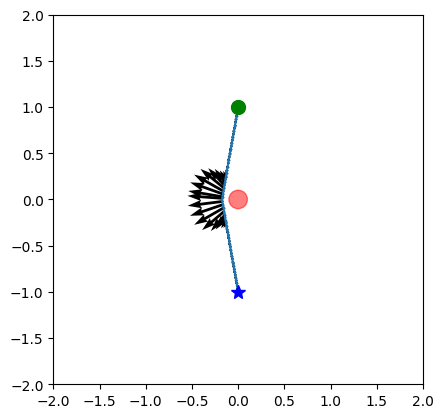

In [45]:
from ael.visualize import visualize
from ael.score_function import (
    compute_velocity_score_batched_helper,
    compute_agent_obstacle_score_from_problem,
)

problem = Problem(
    num_timesteps=64,
    agent_start_positions=np.array([[0.0, 1.0]]),
    agent_end_positions=np.array([[0.0, -1.0]]),
    agent_reference_trajectory=None,
    agent_radii=np.array([0.05]),
    agent_max_speeds=np.array([0.05]),
    obstacle_positions=np.array([[0.0, 0.0]]),
    obstacle_radii=np.array([0.1]),
)
# visualize(problem, plt.gca())
# plt.xlim(-2, 2)
# plt.ylim(-2, 2)
# plt.show()
result = solve(
    problem,
    ScoreComputationMethod.APPROXIMATE_V0,
    identifier="test",
)
# result.trajectories[-1]
# Get velocities
traj = result.trajectories[-1]
velocities = np.linalg.norm(np.diff(traj, axis=0)[:, 0, :], axis=-1)
# print("Velocities:\n", velocities)

xy_T_B_D = traj
v_score = compute_velocity_score_batched_helper(
    xy_T_B_D,
    problem.agent_max_speeds,
    np.ones(problem.num_agents) * 0.001,
)
visualize(problem, plt.gca(), result.trajectories[-1])

o_score, a_score = compute_agent_obstacle_score_from_problem(
    problem,
    xy_T_B_D,
    sigma=0.1,
    n_integral=20,
)

plt.quiver(
    xy_T_B_D[:, 0, 0],
    xy_T_B_D[:, 0, 1],
    v_score[:, 0, 0],
    v_score[:, 0, 1],
    scale=100,
)

plt.quiver(
    xy_T_B_D[:, 0, 0],
    xy_T_B_D[:, 0, 1],
    o_score[:, 0, 0, 0],
    o_score[:, 0, 0, 1],
    scale=100,
)

plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.show()

# compute the score function for this trajectory
